# 🔍 One-Class SVM — Anomali Tespiti

**One-Class SVM**, yalnızca **normal (pozitif) veriyle** eğitilen bir anomali tespit algoritmasıdır.  
Test sırasında, modelin öğrendiği "normal" bölgenin **dışına** düşen noktalar **anormal (outlier)** olarak işaretlenir.

---

### 📌 Kullanım Senaryoları
- Ağ güvenliği (anormal trafik tespiti)
- Üretim hattı kalite kontrolü
- Dolandırıcılık tespiti
- Tıbbi anomali tespiti

---

## 📦 1. Kütüphanelerin İçe Aktarılması

In [1]:
# numpy: sayısal hesaplamalar ve dizi işlemleri için temel kütüphane
import numpy as np

# matplotlib: grafik ve görselleştirme kütüphanesi
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches   # grafik açıklamaları (legend) için

# sklearn: makine öğrenmesi araçları
from sklearn.svm import OneClassSVM          # One-Class SVM modeli
from sklearn.preprocessing import StandardScaler  # özellik ölçekleme
from sklearn.datasets import make_blobs      # yapay veri üretici

print("✅ Tüm kütüphaneler başarıyla yüklendi.")

✅ Tüm kütüphaneler başarıyla yüklendi.


## 🗂️ 2. Veri Üretimi

Gerçek hayattaki senaryo:  
- **Eğitim verisi** → yalnızca **normal** makinelerin titreşim ölçümleri  
- **Test verisi** → normal + arızalı (anormal) makinelerin ölçümleri

In [2]:
# Tekrar üretilebilirlik için rastgele tohum sabitliyoruz
# (Aynı kodu çalıştırdığımızda hep aynı veriyi elde ederiz)
np.random.seed(42)

# ─── EĞİTİM VERİSİ ─────────────────────────────────────────────────────────
# make_blobs: belirtilen merkez etrafında Gaussian (çan eğrisi) dağılımlı veri üretir
# n_samples=300  → 300 adet normal nokta
# centers=[[0,0]]→ kümenin merkezi koordinatı
# cluster_std=0.5→ noktaların merkezden ne kadar yayıldığı (düşük = sıkı küme)
X_train, _ = make_blobs(
    n_samples=300,
    centers=[[0, 0]],
    cluster_std=0.5,
    random_state=42
)

# ─── TEST VERİSİ ────────────────────────────────────────────────────────────
# 80 adet normal nokta (eğitimdekiyle aynı dağılım)
X_test_normal, _ = make_blobs(
    n_samples=80,
    centers=[[0, 0]],
    cluster_std=0.5,
    random_state=10
)

# 20 adet anormal nokta: [-4,4] aralığında tek tip (uniform) dağılımlı rastgele noktalar
# Bu noktalar normal kümenin çok dışında yer alır → gerçek anomaliler
X_test_anomaly = np.random.uniform(low=-4, high=4, size=(20, 2))

# Normal ve anormal test noktalarını tek bir dizi haline getiriyoruz
X_test = np.vstack([X_test_normal, X_test_anomaly])  # vstack: dikey yığma (satır ekleme)

# Gerçek etiketler (değerlendirme için — modele verilmiyor!)
# sklearn kuralı: +1 = normal,  -1 = anormal
y_test_true = np.array(
    [1] * len(X_test_normal) +   # 80 normal → +1
    [-1] * len(X_test_anomaly)   # 20 anormal → -1
)

print(f"Eğitim seti boyutu  : {X_train.shape}  → {X_train.shape[0]} normal nokta")
print(f"Test seti boyutu    : {X_test.shape}   → {len(X_test_normal)} normal + {len(X_test_anomaly)} anormal")

Eğitim seti boyutu  : (300, 2)  → 300 normal nokta
Test seti boyutu    : (100, 2)   → 80 normal + 20 anormal


## ⚖️ 3. Özellik Ölçekleme (Feature Scaling)

SVM, özellikler arasındaki **ölçek farklılıklarına** çok duyarlıdır.  
`StandardScaler`: her özelliği **ortalama=0, standart sapma=1** olacak şekilde dönüştürür.  

> ⚠️ **Kritik Kural**: Scaler **yalnızca eğitim verisiyle** fit edilir.  
> Test verisi aynı parametrelerle sadece **transform** edilir (data leakage önlenir).

In [3]:
# Ölçekleyiciyi oluştur
scaler = StandardScaler()

# fit_transform: eğitim verisinden ortalama ve std öğren, sonra dönüştür
X_train_scaled = scaler.fit_transform(X_train)

# transform: sadece dönüştür (eğitimdeki parametreleri kullan)
# → test verisi için scaler'ı yeniden fit ETME!
X_test_scaled = scaler.transform(X_test)

print(f"Eğitim verisi — Ortalama: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Eğitim verisi — Std Dev : {X_train_scaled.std(axis=0).round(4)}")
print("\n✅ Ölçekleme tamamlandı (ortalama≈0, std≈1 olmalı)")

Eğitim verisi — Ortalama: [ 0. -0.]
Eğitim verisi — Std Dev : [1. 1.]

✅ Ölçekleme tamamlandı (ortalama≈0, std≈1 olmalı)


## 🤖 4. Model Tanımı ve Hiperparametreler

| Parametre | Açıklama | Örnek Değer |
|-----------|----------|---------|
| `kernel` | Veriyi yüksek boyuta taşıyan çekirdek fonksiyonu | `'rbf'` (en yaygın) |
| `nu` | **Beklenen anomali oranı** ve destek vektörü üst sınırı `(0,1]` | `0.05` |
| `gamma` | RBF çekirdeğinin genişliği; `'scale'` → `1/(n_features * X.var())` | `'scale'` |

In [4]:
# ─── One-Class SVM Modeli ───────────────────────────────────────────────────
model = OneClassSVM(
    kernel='rbf',   # Radial Basis Function: noktalar arası mesafeyi Gauss fonksiyonuyla ölçer
                    # → doğrusal olmayan sınırlar çizebilir

    nu=0.05,        # ν (nu) — çift anlamlı hiperparametre:
                    #   1) Eğitim verisi içindeki kabul edilen maksimum 'outlier' oranı
                    #   2) Destek vektörü oranının alt sınırı
                    # Düşük nu → sıkı sınır (az tolerans), Yüksek nu → gevşek sınır

    gamma='scale'   # RBF genişlik parametresi γ (gamma)
                    # 'scale' → 1 / (n_features × X.var())  [sklearn önerisi]
                    # Büyük gamma → dar, keskin sınır | Küçük gamma → geniş, yumuşak sınır
)

print("✅ Model oluşturuldu:")
print(model)

✅ Model oluşturuldu:
OneClassSVM(nu=0.05)


## 🏋️ 5. Modeli Eğitme

> One-Class SVM, **yalnızca normal veriden** öğrenir.  
> Hedef etiket (`y`) **verilmez** → bu bir **unsupervised (gözetimsiz)** öğrenme adımıdır.

In [5]:
# fit(): sadece eğitim verisini gör, "normal" bölgeyi öğren
# Etiket (y) verilmiyor → gözetimsiz öğrenme!
model.fit(X_train_scaled)

# Eğitim verisini de tahmin edelim — kaç nokta 'outlier' sayıldı?
train_predictions = model.predict(X_train_scaled)

# predict() çıktısı: +1 = normal (inlier), -1 = anormal (outlier)
n_inliers_train  = (train_predictions ==  1).sum()
n_outliers_train = (train_predictions == -1).sum()

print(f"✅ Model eğitildi — {X_train_scaled.shape[0]} normal nokta kullanıldı")
print(f"\nEğitim verisi üzerindeki sonuçlar:")
print(f"  Normal  (+1): {n_inliers_train}")
print(f"  Anormal (-1): {n_outliers_train}  ← nu={model.nu} nedeniyle beklenen ≈ {int(len(X_train)*model.nu)} nokta")

✅ Model eğitildi — 300 normal nokta kullanıldı

Eğitim verisi üzerindeki sonuçlar:
  Normal  (+1): 280
  Anormal (-1): 20  ← nu=0.05 nedeniyle beklenen ≈ 15 nokta


## 🔮 6. Test Verisi Üzerinde Tahmin

In [6]:
# predict(): her nokta için +1 (normal) veya -1 (anormal) döner
y_pred = model.predict(X_test_scaled)

# decision_function(): karar sınırına olan uzaklığı (skor) döner
# Pozitif skor  → normal bölgenin içinde
# Negatif skor  → normal bölgenin dışında (anomali)
# Sıfıra yakın  → sınır üzerinde (belirsiz)
scores = model.decision_function(X_test_scaled)

# ─── Tahmin Sonuçlarını Analiz Et ───────────────────────────────────────────
# Doğru tahminleri bul: tahmin ile gerçek etiket örtüşüyor mu?
correct_mask = (y_pred == y_test_true)  # boolean dizi
accuracy = correct_mask.mean() * 100    # yüzde olarak

# Karmaşıklık matrisi bileşenleri:
TP = ((y_pred ==  1) & (y_test_true ==  1)).sum()  # Gerçek Pozitif  : normal → normal
TN = ((y_pred == -1) & (y_test_true == -1)).sum()  # Gerçek Negatif : anormal → anormal
FP = ((y_pred ==  1) & (y_test_true == -1)).sum()  # Yanlış Pozitif : anormal → normal (kaçırdık!)
FN = ((y_pred == -1) & (y_test_true ==  1)).sum()  # Yanlış Negatif : normal  → anormal (aşırı hassas)

print("📊 TEST SONUÇLARI")
print("=" * 40)
print(f"Genel Doğruluk         : %{accuracy:.1f}")
print()
print(f"Gerçek Pozitif  (TP)  : {TP:3d}  ✅ Normal,  doğru tahmin")
print(f"Gerçek Negatif  (TN)  : {TN:3d}  ✅ Anormal, doğru tahmin")
print(f"Yanlış Pozitif  (FP)  : {FP:3d}  ❌ Anormal, normal diye geçti")
print(f"Yanlış Negatif  (FN)  : {FN:3d}  ❌ Normal,  anormal diye işaretlendi")
print()
print(f"Karar skoru — Min: {scores.min():.3f} | Maks: {scores.max():.3f} | Ort: {scores.mean():.3f}")

📊 TEST SONUÇLARI
Genel Doğruluk         : %93.0

Gerçek Pozitif  (TP)  :  73  ✅ Normal,  doğru tahmin
Gerçek Negatif  (TN)  :  20  ✅ Anormal, doğru tahmin
Yanlış Pozitif  (FP)  :   0  ❌ Anormal, normal diye geçti
Yanlış Negatif  (FN)  :   7  ❌ Normal,  anormal diye işaretlendi

Karar skoru — Min: -1.936 | Maks: 0.152 | Ort: -0.309


## 📊 7. Karar Sınırı Görselleştirmesi

Modelin öğrendiği **normal bölgeyi** ve **anomali tespitini** iki boyutlu uzayda görselleştirelim.

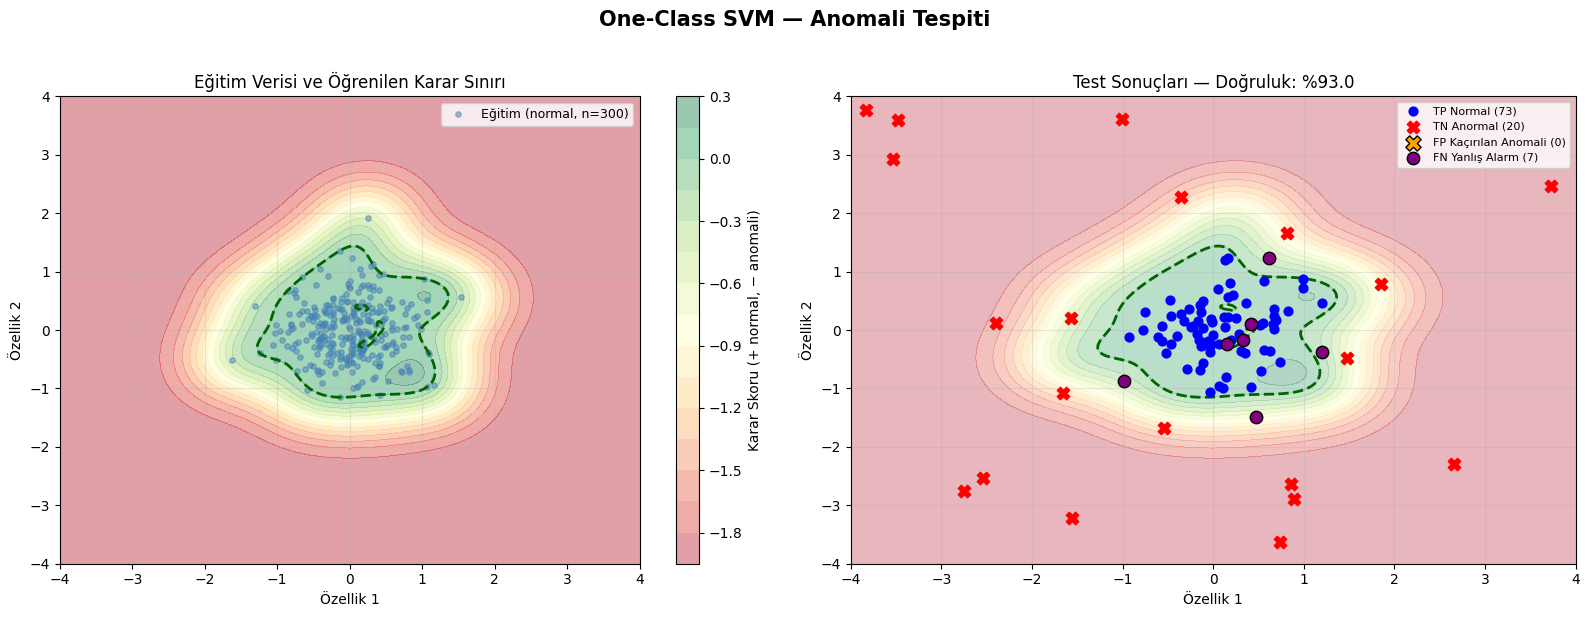

📸 Grafik kaydedildi: one_class_svm_sonuclar.png


In [7]:
# ─── Karar Yüzeyi İçin Izgara Oluştur ───────────────────────────────────────
# 2D uzayı eşit aralıklı noktalarla kapla → model hangi bölgeyi normal sayıyor?
xx, yy = np.meshgrid(
    np.linspace(-4, 4, 300),  # x ekseni: -4'ten +4'e 300 eşit nokta
    np.linspace(-4, 4, 300)   # y ekseni: -4'ten +4'e 300 eşit nokta
)  # xx, yy: her biri (300×300) boyutlu matris

# Izgara noktalarını (300×300) → (90000×2) matrise çevir
# Her satır bir nokta: [x_koordinatı, y_koordinatı]
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Izgara noktalarını da aynı scaler ile dönüştür (tutarlılık için!)
grid_scaled = scaler.transform(grid_points)

# Her ızgara noktası için karar skorunu hesapla
# Negatif → anomali bölgesi | Pozitif → normal bölge
Z = model.decision_function(grid_scaled)

# Skoru 300×300 matrisine yeniden şekillendir (görselleştirme için)
Z = Z.reshape(xx.shape)

# ─── Grafik Oluştur ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('One-Class SVM — Anomali Tespiti', fontsize=15, fontweight='bold', y=1.02)

# ── PANEL 1: Karar Sınırı + Eğitim Verisi ──────────────────────────────────
ax1 = axes[0]

# contourf: dolgulu kontur haritası — arka planı karar skoruna göre renklendir
# levels=20 → 20 renk katmanı | cmap='RdYlGn' → kırmızı(anomali)→sarı→yeşil(normal)
cf = ax1.contourf(xx, yy, Z, levels=20, cmap='RdYlGn', alpha=0.4)
plt.colorbar(cf, ax=ax1, label='Karar Skoru (+ normal, − anomali)')

# contour: karar sınırı çizgisi (skor=0 olan kontur)
ax1.contour(xx, yy, Z, levels=[0], linewidths=2, colors='darkgreen', linestyles='--')

# Eğitim noktalarını çiz
ax1.scatter(
    X_train[:, 0], X_train[:, 1],  # orijinal (ölçeklenmemiş) koordinatlar
    c='steelblue', s=15, alpha=0.5, label=f'Eğitim (normal, n={len(X_train)})'
)

ax1.set_title('Eğitim Verisi ve Öğrenilen Karar Sınırı', fontsize=12)
ax1.set_xlabel('Özellik 1')
ax1.set_ylabel('Özellik 2')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── PANEL 2: Test Sonuçları ─────────────────────────────────────────────────
ax2 = axes[1]

# Aynı arka plan renk haritasını çiz
ax2.contourf(xx, yy, Z, levels=20, cmap='RdYlGn', alpha=0.3)
ax2.contour(xx, yy, Z, levels=[0], linewidths=2, colors='darkgreen', linestyles='--')

# Test noktalarını 4 kategoriye ayır ve farklı renk/şekille çiz
# Doğru Normal (TP): gerçek normal, normal tahminlendi
mask_TP = (y_pred ==  1) & (y_test_true ==  1)
ax2.scatter(X_test[mask_TP, 0], X_test[mask_TP, 1],
            c='blue', marker='o', s=40, label=f'TP Normal ({mask_TP.sum()})', zorder=5)

# Doğru Anormal (TN): gerçek anormal, anormal tahminlendi
mask_TN = (y_pred == -1) & (y_test_true == -1)
ax2.scatter(X_test[mask_TN, 0], X_test[mask_TN, 1],
            c='red', marker='X', s=80, label=f'TN Anormal ({mask_TN.sum()})', zorder=5)

# Yanlış Pozitif (FP): gerçek anormal ama normal tahminlendi — KAÇAN ANOMALİ!
mask_FP = (y_pred ==  1) & (y_test_true == -1)
ax2.scatter(X_test[mask_FP, 0], X_test[mask_FP, 1],
            c='orange', marker='X', s=120, edgecolors='black',
            label=f'FP Kaçırılan Anomali ({mask_FP.sum()})', zorder=6)

# Yanlış Negatif (FN): gerçek normal ama anormal tahminlendi — YANLIŞ ALARM
mask_FN = (y_pred == -1) & (y_test_true ==  1)
ax2.scatter(X_test[mask_FN, 0], X_test[mask_FN, 1],
            c='purple', marker='o', s=80, edgecolors='black',
            label=f'FN Yanlış Alarm ({mask_FN.sum()})', zorder=6)

ax2.set_title(f'Test Sonuçları — Doğruluk: %{accuracy:.1f}', fontsize=12)
ax2.set_xlabel('Özellik 1')
ax2.set_ylabel('Özellik 2')
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('one_class_svm_sonuclar.png', dpi=150, bbox_inches='tight')
plt.show()
print("📸 Grafik kaydedildi: one_class_svm_sonuclar.png")

## 🔬 8. Nu Parametresinin Etkisi

`nu` değerini değiştirdiğimizde model nasıl davranır?  
- **Küçük nu** → Sıkı sınır, az outlier kabul eder → Yüksek FN riski  
- **Büyük nu** → Gevşek sınır, fazla outlier kabul eder → Yüksek FP riski

In [8]:
# Test edilecek nu değerleri listesi
nu_values = [0.01, 0.05, 0.10, 0.20, 0.30]

# Her nu için sonuçları sakla
results = []

for nu in nu_values:
    # Her nu için ayrı bir model oluştur ve eğit
    m = OneClassSVM(kernel='rbf', nu=nu, gamma='scale')
    m.fit(X_train_scaled)
    
    # Test verisi üzerinde tahmin yap
    preds = m.predict(X_test_scaled)
    
    # Metrikleri hesapla
    tp = ((preds ==  1) & (y_test_true ==  1)).sum()  # Doğru normal
    tn = ((preds == -1) & (y_test_true == -1)).sum()  # Doğru anormal
    fp = ((preds ==  1) & (y_test_true == -1)).sum()  # Kaçan anomali
    fn = ((preds == -1) & (y_test_true ==  1)).sum()  # Yanlış alarm
    acc = (preds == y_test_true).mean() * 100
    
    results.append({'nu': nu, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn, 'Acc': acc})

# ─── Sonuçları Tablo Olarak Yazdır ──────────────────────────────────────────
print("┌────────┬──────┬──────┬──────┬──────┬──────────┐")
print("│   nu   │  TP  │  TN  │  FP  │  FN  │ Doğruluk │")
print("├────────┼──────┼──────┼──────┼──────┼──────────┤")
for r in results:
    print(f"│ {r['nu']:.2f}   │ {r['TP']:4d} │ {r['TN']:4d} │ {r['FP']:4d} │ {r['FN']:4d} │  %{r['Acc']:5.1f}   │")
print("└────────┴──────┴──────┴──────┴──────┴──────────┘")
print("\nTP=Doğru Normal | TN=Doğru Anormal | FP=Kaçan Anomali | FN=Yanlış Alarm")

┌────────┬──────┬──────┬──────┬──────┬──────────┐
│   nu   │  TP  │  TN  │  FP  │  FN  │ Doğruluk │
├────────┼──────┼──────┼──────┼──────┼──────────┤
│ 0.01   │   69 │   20 │    0 │   11 │  % 89.0   │
│ 0.05   │   73 │   20 │    0 │    7 │  % 93.0   │
│ 0.10   │   68 │   20 │    0 │   12 │  % 88.0   │
│ 0.20   │   63 │   20 │    0 │   17 │  % 83.0   │
│ 0.30   │   56 │   20 │    0 │   24 │  % 76.0   │
└────────┴──────┴──────┴──────┴──────┴──────────┘

TP=Doğru Normal | TN=Doğru Anormal | FP=Kaçan Anomali | FN=Yanlış Alarm


## 📈 9. Nu Karşılaştırma Grafiği

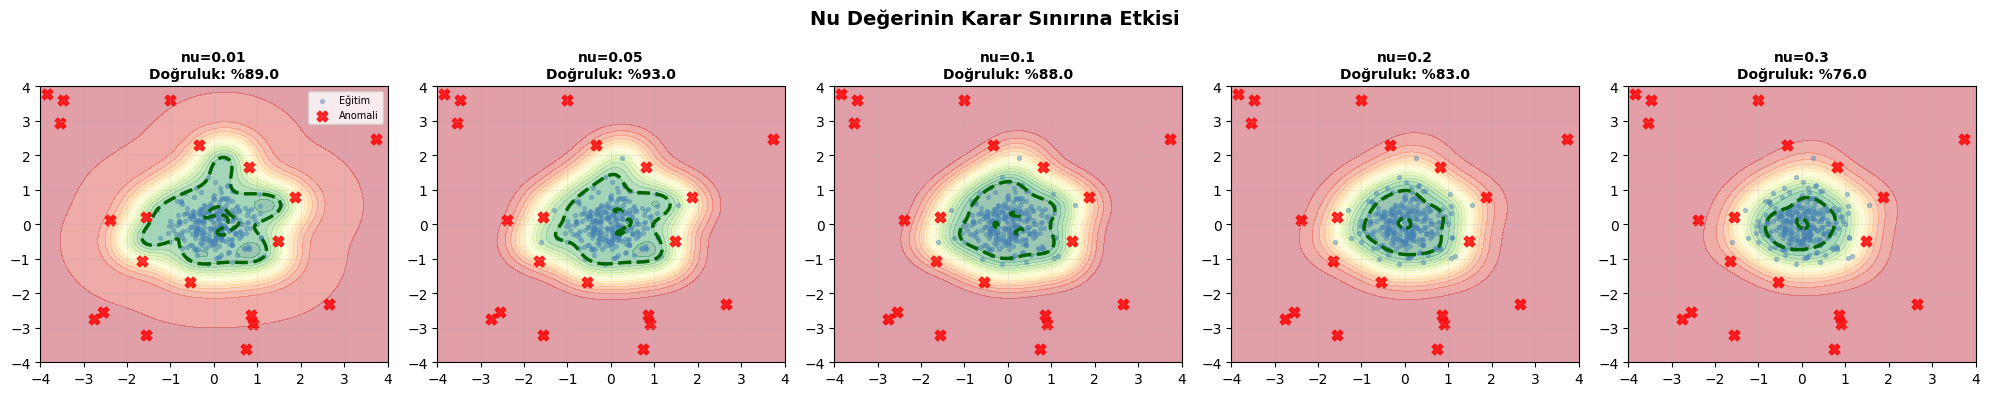

📸 Grafik kaydedildi: nu_karsilastirma.png


In [9]:
fig, axes = plt.subplots(1, len(nu_values), figsize=(20, 4))
fig.suptitle('Nu Değerinin Karar Sınırına Etkisi', fontsize=14, fontweight='bold')

for i, nu in enumerate(nu_values):
    ax = axes[i]
    
    # Bu nu değeri için model eğit
    m = OneClassSVM(kernel='rbf', nu=nu, gamma='scale')
    m.fit(X_train_scaled)
    
    # Karar yüzeyini hesapla
    Z_nu = m.decision_function(grid_scaled).reshape(xx.shape)
    
    # Arka planı renklendir
    ax.contourf(xx, yy, Z_nu, levels=15, cmap='RdYlGn', alpha=0.4)
    
    # Karar sınırını çiz (skor=0 kontur)
    ax.contour(xx, yy, Z_nu, levels=[0], linewidths=2.5,
               colors='darkgreen', linestyles='--')
    
    # Eğitim noktalarını küçük nokta olarak göster
    ax.scatter(X_train[:, 0], X_train[:, 1],
               c='steelblue', s=8, alpha=0.4, label='Eğitim')
    
    # Test anomalilerini kırmızı X ile göster
    ax.scatter(X_test_anomaly[:, 0], X_test_anomaly[:, 1],
               c='red', marker='X', s=60, alpha=0.8, label='Anomali')
    
    # Başlık: nu değeri ve doğruluk
    acc = results[i]['Acc']
    ax.set_title(f'nu={nu}\nDoğruluk: %{acc:.1f}', fontsize=10, fontweight='bold')
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.grid(True, alpha=0.2)
    if i == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('nu_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print("📸 Grafik kaydedildi: nu_karsilastirma.png")

## 📋 10. Özet ve Sonuçlar

---

### 🎯 One-Class SVM'in Çalışma Mantığı

```
Eğitim:  Normal veri → [One-Class SVM] → Karar sınırı öğrenir
Test:    Yeni veri   → [Sınır içinde?] → Normal (+1) veya Anormal (-1)
```

### ✅ Avantajlar
- Anormal veri **gerekmez** — gerçek hayatta çok değerli
- RBF çekirdeği sayesinde **doğrusal olmayan** sınırlar çizebilir
- `nu` ile anomali toleransı **ayarlanabilir**

### ⚠️ Sınırlamalar  
- Yüksek boyutlu veride performans düşer
- `nu` ve `gamma` seçimi **deneyim gerektirior**
- Gerçek anomali oranı bilinmeden `nu` seçimi zor

### 🔧 Hiperparametre Rehberi
| Durum | Önerilen nu |
|-------|-------------|
| Anomali nadir (`<1%`) | 0.01 – 0.05 |
| Anomali az (`~5%`) | 0.05 – 0.10 |
| Anomali orta (`~15%`) | 0.10 – 0.20 |

In [10]:
# Final Özet
print("=" * 50)
print("     ONE-CLASS SVM — SONUÇ ÖZETİ")
print("=" * 50)
print(f"  Eğitim seti    : {len(X_train)} normal nokta")
print(f"  Test seti      : {len(X_test)} nokta ({len(X_test_normal)} normal + {len(X_test_anomaly)} anormal)")
print(f"  Kernel         : RBF")
print(f"  Nu (seçilen)   : {model.nu}")
print(f"  Genel Doğruluk : %{accuracy:.1f}")
print(f"  Tespit Edilen  : {TN}/{len(X_test_anomaly)} anomali (%{TN/len(X_test_anomaly)*100:.0f})")
print("=" * 50)
print("\n✅ Notebook başarıyla tamamlandı!")

     ONE-CLASS SVM — SONUÇ ÖZETİ
  Eğitim seti    : 300 normal nokta
  Test seti      : 100 nokta (80 normal + 20 anormal)
  Kernel         : RBF
  Nu (seçilen)   : 0.05
  Genel Doğruluk : %93.0
  Tespit Edilen  : 20/20 anomali (%100)

✅ Notebook başarıyla tamamlandı!
